# Benchmarking against MASIF ligand

MASIF ligand is set up as a multi-class classification problem.

* Which protein chain is the pocket? We can use all chains specified by the MASIF PDB chain ID's and just pair them with the ligand.
* PDB chain IDs with multiple distinct ligands. But the coordinates are distinct, so they should just be treated as separate examples.
* PDB chain IDs with multiple same ligands. We can deduplicate and just pick one example? 
* TODO: check on the class imbalance across the ligands.

In [ ]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import os
import numpy as np
import biotite.structure as bs
import biotite.structure.io.pdb as pdb
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt

from atomica.data.converter import ligand_utils
from atomica.data import filter_for_segment

masif_labels = ["ADP", "COA", "FAD", "HEM", "NAD", "NAP", "SAM"]

MASIF_DATA_DIR = "/n/holylabs/LABS/mzitnik_lab/Users/afang/ATOMICA/baselines/masif/data/masif_ligand/lists/"
MASIF_LIGAND_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00c-ligand_coords/"
PDB_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/00b-pdbs_assembly/"
ATOMICA_DATA_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/atomica_ligand/"

## Protein-Ligand structures to process

In [14]:
def get_chains_for_ligand(pdb_id: str, lig_code: str) -> list[str]:
    """
    Get the chains for a given ligand code.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    ligand = structure[:, structure.res_name == lig_code]
    ligand = list(zip(ligand.chain_id, ligand.res_id))
    return list(set(ligand))


def get_chains(pdb_id: str) -> list[str]:
    """
    Get the chains for a given PDB ID.
    """
    pdb_path = PDB_DIR + f"{pdb_id}.pdb"
    if not os.path.exists(pdb_path):
        raise FileNotFoundError(f"PDB file not found for {pdb_id}")
    pdb_file = pdb.PDBFile.read(pdb_path)
    structure = pdb_file.get_structure()
    structure = structure[:, bs.filter_canonical_amino_acids(structure)]
    chains = list(set(structure.chain_id))
    return chains

In [15]:
to_process = []

with open(os.path.join(MASIF_DATA_DIR, "sequence_split_list.txt"), "r") as f:
    lines = f.readlines()
pdb_chain_ids = [line.strip() for line in lines]

for pdb_chain_id in tqdm(pdb_chain_ids, desc="Processing PDB chain IDs", total=len(pdb_chain_ids)):
    pdb_id = pdb_chain_id.split("_")[0]
    ligand_type = MASIF_LIGAND_DIR + f"{pdb_id}_ligand_types.npy"
    ligands = np.load(ligand_type)
    ligands = ligands.astype(str)
    for ligand in np.unique(ligands):
        lig_chains = get_chains_for_ligand(pdb_id, ligand)
        rec_chains = pdb_chain_id.split("_")[1]
        valid_chains = get_chains(pdb_id)
        rec_chains = [chain for chain in rec_chains if chain in valid_chains]
        for lig_chain, lig_resi in lig_chains:
            to_process.append({
                "pdb_id": pdb_id,
                "pdb_path": PDB_DIR + f"{pdb_id}.pdb",
                "chain1": "_".join(rec_chains),
                "chain2": lig_chain,
                "lig_code": ligand,
                "lig_resi": lig_resi,
            })

to_process_df = pd.DataFrame(to_process)
to_process_df['label'] = to_process_df['lig_code'].map(lambda x: masif_labels.index(x))
to_process_df['lig_smiles'] = to_process_df['lig_code'].apply(lambda x: ligand_utils.get_ligand_smiles(x))


Processing PDB chain IDs: 100%|██████████| 1468/1468 [03:02<00:00,  8.03it/s]


In [16]:
to_process_df['lig_code'].value_counts()

lig_code
ADP    757
HEM    473
FAD    446
COA    339
NAD    306
SAM    260
NAP    218
Name: count, dtype: int64

In [17]:
to_process_df.to_csv("masif_ligand_pdbs_to_process.csv", index=False)

Run `process_masif_ligand_pdbs.sh` to process the PDBs.

## Remove the ligand residues from the processed graphs

In [83]:
df = pd.read_parquet(ATOMICA_DATA_DIR + "masif_ligand_pdbs_12A.parquet")
df = df.drop_duplicates(subset=['id']) # if there are multiple ligands on the same chain, drop the duplicates

# Filter for only the pocket residues
data_cols = ['X','B','A','atom_positions','block_lengths','segment_ids'] 
filtered_data = df.apply(
    lambda row: filter_for_segment({k: row[k] for k in data_cols}, 0), axis=1
)
df[data_cols] = pd.json_normalize(filtered_data).to_numpy()
df.to_parquet(ATOMICA_DATA_DIR + "masif_ligand_pdbs_12A_pocket_only.parquet")

Compare pocket sizes, FAD is the largest pocket and ADP is the smallest.

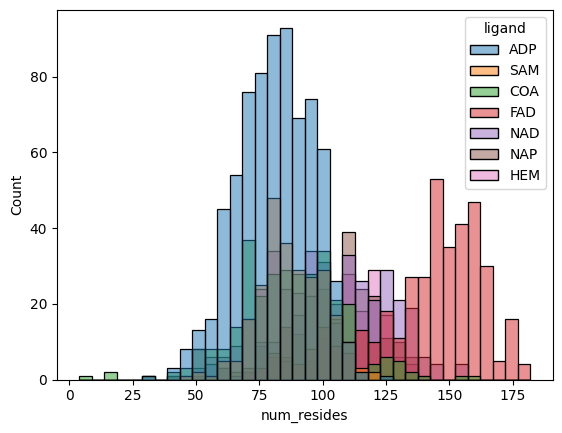

In [ ]:
pocket_size = pd.DataFrame({
    'num_resides': df['B'].apply(lambda x: len(x)), 
    'ligand': df['id'].str.split('_').str[-1]
})
pocket_size.groupby('ligand').agg(
    mean_num_resides=('num_resides', 'mean'),
    std_num_resides=('num_resides', 'std'),
)

sns.histplot(pocket_size, x='num_resides', hue='ligand')
plt.show()

## Train test splits

In [40]:
def _clean_pdb_chain_id(pdb_chain_id: str) -> str:
    pdb_id, chain_ids, *_ = pdb_chain_id.split('_')
    chain_ids = "".join(sorted(chain_ids))
    return pdb_id + "_" + chain_ids

train = np.load(os.path.join(MASIF_DATA_DIR, "train_pdbs_sequence.npy"))
train = train.astype(str)  # Convert byte strings to regular strings
train = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in train]

val = np.load(os.path.join(MASIF_DATA_DIR, "val_pdbs_sequence.npy"))
val = val.astype(str)  # Convert byte strings to regular strings
val = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in val]

test = np.load(os.path.join(MASIF_DATA_DIR, "test_pdbs_sequence.npy"))
test = test.astype(str)  # Convert byte strings to regular strings
test = [_clean_pdb_chain_id(pdb_chain_id) for pdb_chain_id in test]

print(f"Train: {len(train)}, Val: {len(val)}, Test: {len(test)}")
print(f"Train val overlap: {len(set(train) & set(val))}")
print(f"Test val overlap: {len(set(test) & set(val))}")

Train: 1036, Val: 115, Test: 287
Train val overlap: 0
Test val overlap: 0


In [84]:
def _assign_split(item_id: str) -> str:
    pdb_chain_id = _clean_pdb_chain_id(item_id)
    if pdb_chain_id in train:
        return 'train'
    elif pdb_chain_id in val:
        return 'val'
    elif pdb_chain_id in test:
        return 'test'

df = pd.read_parquet(ATOMICA_DATA_DIR + "masif_ligand_pdbs_12A_pocket_only.parquet")
df['split'] = df['id'].apply(_assign_split)
df.loc[df['id'] == '1FFT_ACB_A_HEM', 'split'] = 'train' # 1FFT_ABCD is in the train set of MASIF

assert not df['split'].isna().any()

# Keep only the first ligand per PDB
# A lot of PDBs are symmetric, so we keep only the first ligand per PDB.
# Unclear how MASIF handle this, but this makes the dataset more comparable in size.
df['id_fixed'] = df['id'].apply(lambda x: "_".join(x.split('_')[:2] + x.split('_')[-1:]))
df = df.drop_duplicates('id_fixed')
df.drop(columns=['id_fixed'], inplace=True)

for split in ['train', 'val', 'test']:
    split_df = df[df['split'] == split].copy()
    split_df.drop(columns=['split'], inplace=True)
    print(f"{split}: {len(split_df)}, ligands: {split_df['id'].str.split('_').str[-1].value_counts().to_dict()}")
    split_df.to_parquet(ATOMICA_DATA_DIR + f"masif_ligand_pdbs_12A_pocket_only_{split}.parquet")

train: 1039, ligands: {'ADP': 306, 'FAD': 178, 'HEM': 149, 'SAM': 125, 'COA': 113, 'NAD': 98, 'NAP': 70}
val: 117, ligands: {'ADP': 30, 'FAD': 17, 'HEM': 17, 'COA': 14, 'NAD': 13, 'NAP': 13, 'SAM': 13}
test: 289, ligands: {'ADP': 96, 'FAD': 47, 'HEM': 45, 'SAM': 37, 'COA': 30, 'NAD': 18, 'NAP': 16}


## MASIF predictions

In [1]:
MASIF_PREDICTIONS_DIR = "/n/holylfs06/LABS/mzitnik_lab/Lab/afang/ATOMICA/baselines/MASIF/test_set_predictions"

In [3]:
labels = np.load(os.path.join(MASIF_PREDICTIONS_DIR, "2VRB_AB_labels.npy"))
preds = np.load(os.path.join(MASIF_PREDICTIONS_DIR, "2VRB_AB_logits.npy"))

In [4]:
labels

array([5])

In [6]:
preds.shape

(1, 100, 1, 1, 7)